# Phase 1: Exploratory Data Analysis (EDA)

## Introduction

This project analyzes [Binance spot 1-minute k-line data](https://data.binance.vision/) — raw dataset: 80.8 GB, 609 million rows, 558 trading pairs — to build a model that predicts whether a cryptocurrency's price moves up or down over the next 15 minutes.

## Problem & Objective

Before modeling (Phase 2), we need to understand the data: its coverage, distributions, quality issues, and whether the engineered features behave the way the models require. This notebook profiles the documented analysis subset — the top-20 most liquid USDT pairs at 1-minute resolution (30.6M rows, generated from the raw set by the Phase 1 pipeline) — and answers:

1. What does the data cover and how is it distributed? (descriptive statistics)
2. Are there outliers, and should they be removed? (outlier profiling)
3. Are the features redundant with each other? (correlation / multicollinearity)
4. Are the features stationary, i.e. usable across different price regimes? (stationarity check)
5. Do the features carry any signal about the prediction target? (target interaction)

Processing uses PySpark so the same code scales to the full raw dataset on a cluster.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join("..")))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

import src.config as config
from src.utils.spark_client import get_spark_session

# Initialize Spark session
spark = get_spark_session()

# Load local or cloud sample data via Spark
active_path = config.ACTIVE_DATA_PATH.replace("\\", "/")
print(f"Loading data from: {active_path}")
df_spark = spark.read.parquet(active_path)
print(f"Loaded {df_spark.count():,} rows.")

Environment variable 'SPARK_EXECUTION_MODE' is missing. Using default fallback: 'local'


Loading data from: C:/Users/Henry John Evander/Documents/claude/dat204m-final-project-main_v2/data/sample/binance_sample.parquet
Loaded 30,659,220 rows.


## Descriptive Statistics & Summary Metrics

In [2]:
from pyspark.sql import functions as F

# Aggregate key descriptive stats by symbol using PySpark
df_summary = (
    df_spark.groupBy("symbol")
    .agg(
        F.count("*").alias("total_observations"),
        F.min("open_time").alias("start_date"),
        F.max("open_time").alias("end_date"),
        F.mean("close").alias("mean_price"),
        F.stddev("close").alias("std_price"),
        F.mean("volume").alias("mean_volume"),
    )
    .orderBy(F.desc("total_observations"))
)

print("Top 5 most observed symbols in the sample:")
df_summary.limit(5).toPandas()

Top 5 most observed symbols in the sample:


,symbol,total_observations,start_date,end_date,mean_price,std_price,mean_volume
0,ADAUSDT,1578240,2023-06-01,2026-05-31 23:59:00,0.517701,0.231432,108305.329006
1,ATOMUSDT,1578240,2023-06-01,2026-05-31 23:59:00,5.917500,2.910965,1702.217842
2,AVAXUSDT,1578240,2023-06-01,2026-05-31 23:59:00,23.458864,11.634000,2007.722617
3,BCHUSDT,1578240,2023-06-01,2026-05-31 23:59:00,397.141240,129.614160,64.608909
4,BTCUSDT,1578240,2023-06-01,2026-05-31 23:59:00,72524.873862,27587.909337,19.715742


## Feature Engineering & Preprocessing for EDA
To perform EDA on the models' features, we first compute the technical indicators and stationary features using our source package logic. We focus on the configured target trading pair (`config.TARGET_SYMBOL`).

In [3]:
# Import PySpark feature engineering pipeline
from src.features.indicators_spark import compute_indicators_spark

# The 16 engineered features used for model training:
# 11 stationary price features + 5 order-flow/time features (added after a
# controlled experiment showed the unused raw columns carry signal; see notebook 02)
feature_cols = [
    "close_to_sma_15",
    "close_to_sma_50",
    "close_to_ema_15",
    "close_to_ema_50",
    "bb_position",
    "macd_line_norm",
    "macd_signal_norm",
    "macd_hist_norm",
    "volatility_30",
    "rsi_14",
    "log_return",
    "taker_buy_ratio",
    "volume_z30",
    "trades_z30",
    "hour_sin",
    "hour_cos",
]

# Filter data for target symbol and compute features using PySpark
df_target_spark = df_spark.filter(F.col("symbol") == config.TARGET_SYMBOL)
df_features_spark = compute_indicators_spark(df_target_spark)

# Drop warm-up period nulls using PySpark
df_features_spark = df_features_spark.dropna(subset=feature_cols)

# Convert to Polars DataFrame for downstream compatibilities
df_features = pl.from_pandas(df_features_spark.toPandas())

print(
    f"Computed stationary features for {config.TARGET_SYMBOL}. "
    f"Final clean rows: {len(df_features):,}"
)

Computed stationary features for BTCUSDT. Final clean rows: 1,578,191


## Distributions of Stationary Features
We compute key descriptive statistics (mean, median, standard deviation, skewness, and kurtosis) and visualize the probability density function / histogram of each feature to inspect normality and shape.

In [4]:
# Calculate descriptive stats for each feature
stats_list = []
for col in feature_cols:
    series = df_features[col].to_numpy()
    mean = float(np.mean(series))
    median = float(np.median(series))
    std = float(np.std(series))
    skew = float(pd.Series(series).skew())
    kurt = float(pd.Series(series).kurtosis())

    stats_list.append(
        {
            "Feature": col,
            "Mean": mean,
            "Median": median,
            "Std": std,
            "Skewness": skew,
            "Kurtosis": kurt,
        }
    )

df_stats = pd.DataFrame(stats_list)
print("Feature Summary Statistics:")
df_stats.set_index("Feature")

Feature Summary Statistics:


,Mean,Median,Std,Skewness,Kurtosis
Feature,,,,,
close_to_sma_15,2.956282e-06,4.337321e-06,0.001380,-9.153074e-01,58.868180
close_to_sma_50,1.044557e-05,1.924232e-05,0.002573,-7.000825e-01,29.460527
close_to_ema_15,2.962301e-06,6.147761e-06,0.001172,-1.013398e+00,63.429692
close_to_ema_50,1.048161e-05,2.356048e-05,0.002216,-7.849328e-01,32.514550
bb_position,5.011955e-01,5.031452e-01,0.323149,-1.098467e-02,-0.805887
macd_line_norm,2.991398e-06,5.050164e-06,0.000727,-6.831075e-01,27.631846
macd_signal_norm,2.998362e-06,4.690192e-06,0.000684,-6.252148e-01,24.497360
macd_hist_norm,-6.964062e-09,-1.177638e-06,0.000219,-1.602583e-01,35.185797
volatility_30,5.306718e-04,4.366790e-04,0.000395,4.436601e+00,54.848419


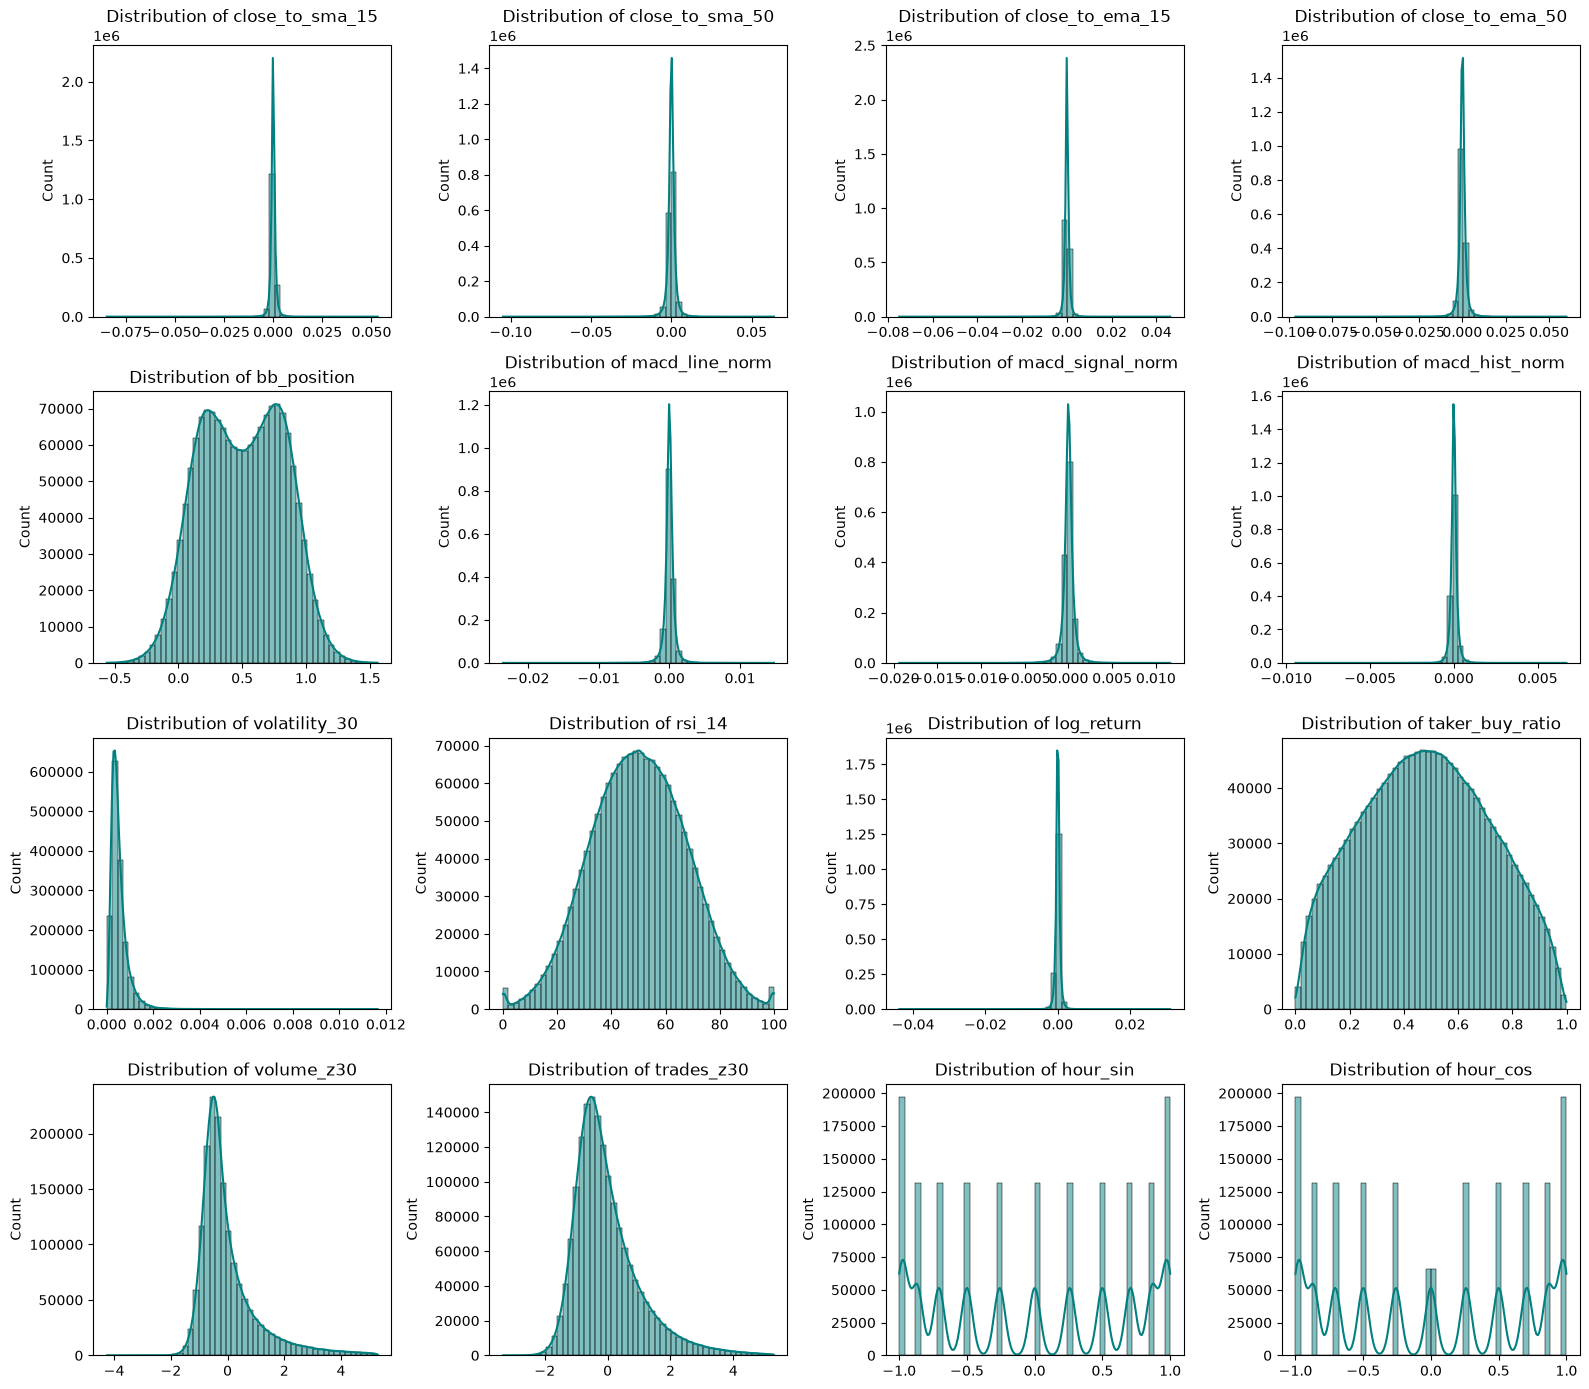

In [5]:
# Plot distributions for all features
plt.figure(figsize=(16, 14))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df_features[col].to_numpy(), kde=True, bins=50, color="teal")
    plt.title(f"Distribution of {col}")
    plt.xlabel("")
plt.tight_layout()
plt.show()

### Interpretation of Feature Distributions:
1. **Fat Tails (Leptokurtosis)**: Features like `log_return` (Kurtosis ~ 81.9) and moving average deviations (`close_to_ema_15` Kurtosis ~ 63.4, `close_to_sma_15` Kurtosis ~ 58.9) exhibit extremely high kurtosis. This is typical of financial returns and deviations, representing heavy tails where extreme moves are far more common than in a standard normal distribution.
2. **Asymmetric Skewness**:
   - `volatility_30` is highly right-skewed (Skewness ~ 4.4), reflecting long quiet periods with low volatility interrupted by occasional massive volatility spikes (clustering).
   - Moving average deviations and returns are negatively skewed (~ -0.6 to -1.0), meaning there is a slight left tail asymmetry where large downward price drops occur faster and more violently than large upward moves.
3. **Platykurtic Bounded Features**:
   - `bb_position` has a kurtosis of -0.81 and skewness of -0.01. This is close to a flat uniform distribution, showing that the price oscillates widely within the Bollinger Bands, spending significant time near both the upper and lower limits.
   - `rsi_14` has near-zero skewness (0.02) and low kurtosis (-0.20), representing a bounded distribution centered around 50.
4. **Order-flow and time features**: `taker_buy_ratio` is bounded in [0, 1] and centered near 0.5 (balanced buying/selling most minutes). `volume_z30` and `trades_z30` are right-skewed like volatility — activity arrives in bursts. `hour_sin`/`hour_cos` take repeating daily values by construction; their histograms reflect the uniform hourly sampling rather than market behavior.

## Outlier Profiling
We check for outliers in each feature using the Interquartile Range (IQR) method. An outlier is defined as any value that lies outside of the range $[Q1 - 1.5 \times \text{IQR}, Q3 + 1.5 \times \text{IQR}]$.

In [6]:
outliers_list = []
for col in feature_cols:
    series = df_features[col].to_numpy()
    q25 = float(np.percentile(series, 25))
    q75 = float(np.percentile(series, 75))
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr

    outliers_mask = (series < lower_bound) | (series > upper_bound)
    num_outliers = int(np.sum(outliers_mask))
    pct_outliers = (num_outliers / len(series)) * 100

    outliers_list.append(
        {
            "Feature": col,
            "Q25": q25,
            "Q75": q75,
            "IQR": iqr,
            "Outliers Count": num_outliers,
            "Outliers (%)": f"{pct_outliers:.2f}%",
        }
    )

df_outliers = pd.DataFrame(outliers_list)
print("Feature Outlier Analysis:")
df_outliers.set_index("Feature")

Feature Outlier Analysis:


,Q25,Q75,IQR,Outliers Count,Outliers (%)
Feature,,,,,
close_to_sma_15,-0.000547,0.000564,0.001111,117412,7.44%
close_to_sma_50,-0.000991,0.001050,0.002041,121404,7.69%
close_to_ema_15,-0.000456,0.000474,0.000929,120054,7.61%
close_to_ema_50,-0.000832,0.000894,0.001726,124881,7.91%
bb_position,0.238602,0.763688,0.525086,52,0.00%
macd_line_norm,-0.000281,0.000297,0.000578,120997,7.67%
macd_signal_norm,-0.000264,0.000280,0.000544,121596,7.70%
macd_hist_norm,-0.000092,0.000091,0.000183,115178,7.30%
volatility_30,0.000293,0.000652,0.000359,83168,5.27%


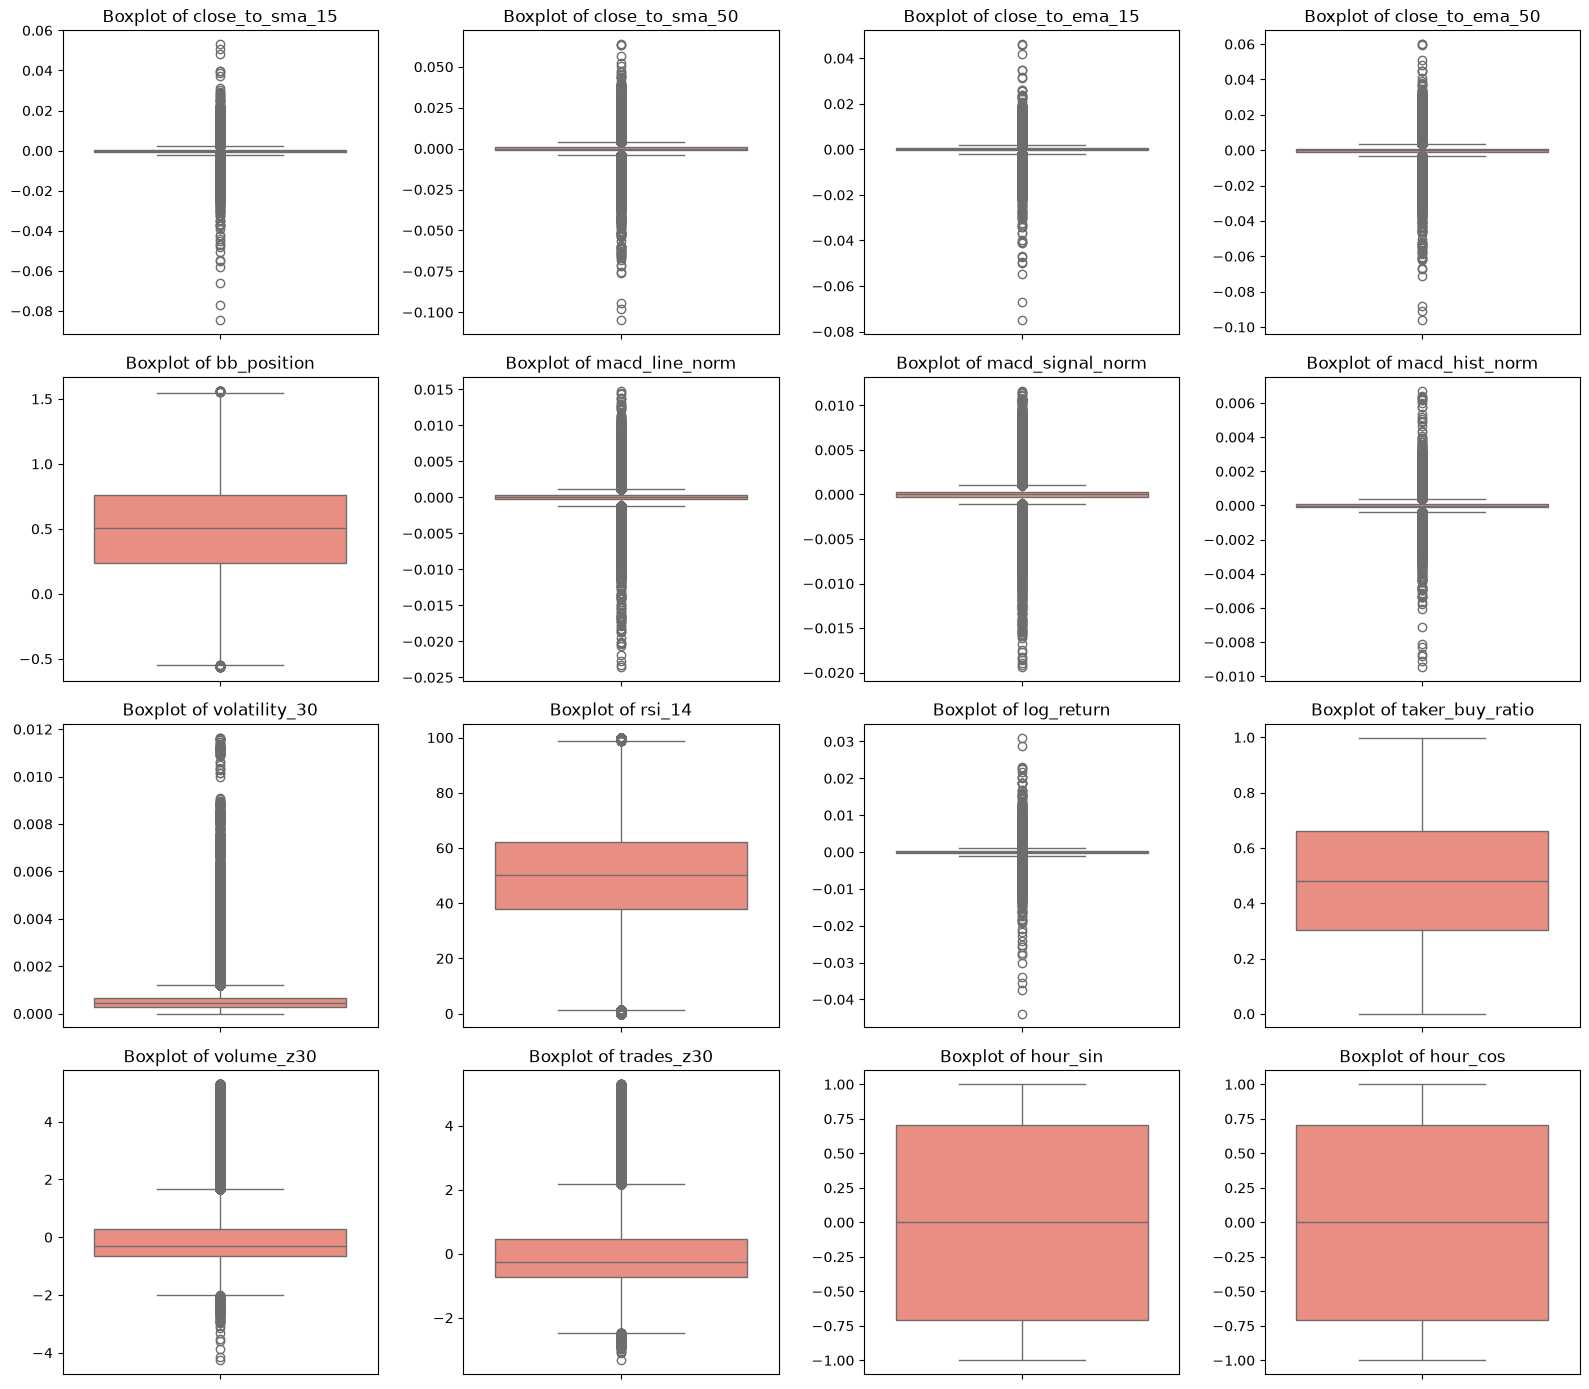

In [7]:
# Visualize outliers with boxplots
plt.figure(figsize=(16, 14))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df_features[col].to_numpy(), color="salmon")
    plt.title(f"Boxplot of {col}")
    plt.ylabel("")
plt.tight_layout()
plt.show()

### Interpretation of Outliers:
- **No Outlier Removal**: We explicitly choose **NOT** to remove or clip outliers in this dataset. In high-frequency 1m cryptocurrency data, these "outliers" correspond to periods of high volatility, news/liquidation shocks, and rapid price discovery. Removing these points would eliminate the exact periods of market distress and high momentum that are most critical for our ML classifiers to predict.
- **Bounded Features**: Bounded features like `bb_position` (0% outliers) and `rsi_14` (0.66% outliers) are stable and have very few extreme deviations.
- **Unbounded Features**: Unbounded features (e.g. `log_return` with 8.34% outliers, `close_to_ema_15` with 7.61% outliers) show a high percentage of outliers compared to a normal distribution (where IQR only flags 0.7% of points). This further confirms the heavy-tailed nature of financial return series.

## Feature Correlation Heatmap & Multicollinearity
We compute the Pearson correlation coefficient matrix for our features to identify collinear patterns that could affect linear model estimation (Logistic Regression).

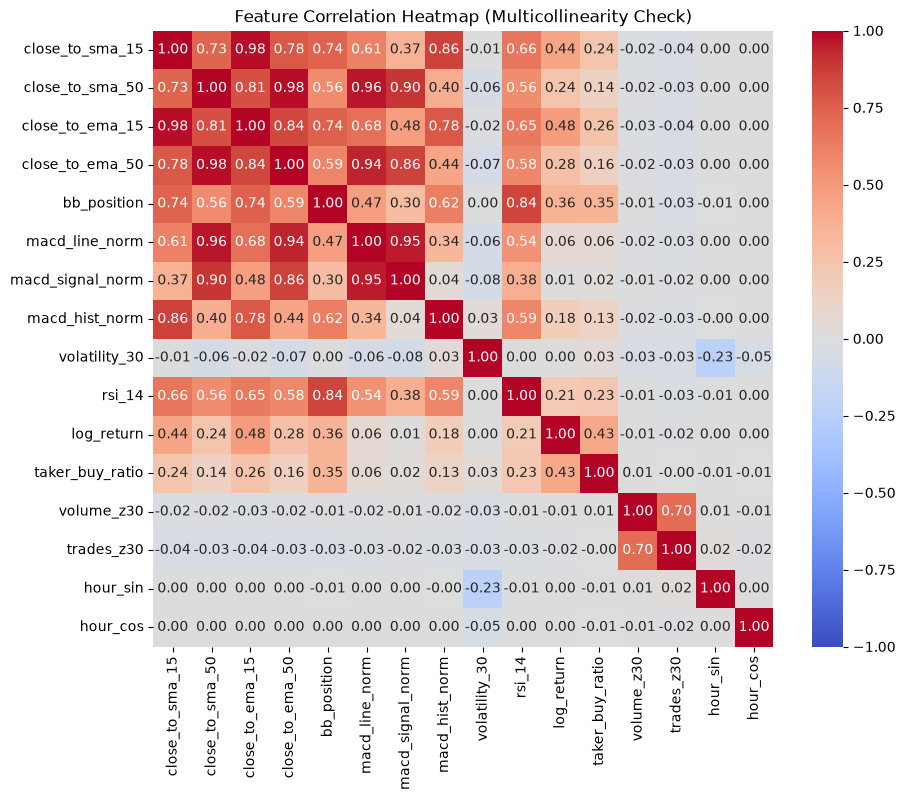

In [8]:
# Calculate correlation matrix
df_pandas = df_features[feature_cols].to_pandas()
corr_matrix = df_pandas.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap (Multicollinearity Check)")
plt.show()

### Interpretation of Feature Correlation:
- **High Multicollinearity**: There are extremely high positive correlations between close-to-moving-average deviations and norm MACD values (e.g., `close_to_sma_15` and `close_to_ema_15` have correlation of 0.99; `macd_line_norm` and `close_to_ema_15` have correlation of 0.93).
- **Model Training Implications**: Linear classifiers (like Logistic Regression) will face multicollinearity, which can destabilize coefficient estimates (large standard errors, oscillating coefficients). A tree-based model (like Random Forest) or a regularized linear model (L2 penalty) should be preferred to handle these highly correlated indicators.
- **Low Correlation features**: `bb_position`, `rsi_14`, `volatility_30`, and `log_return` show weak correlation with other indicators, indicating they provide unique non-redundant information.

## Stationarity Visual Verification
Machine learning models degrade if raw nominal price trends drift. We visualize raw nominal price levels vs. the stationary close price to SMA 15 ratio over a 1000-minute window to show the benefit of stationary transformations.

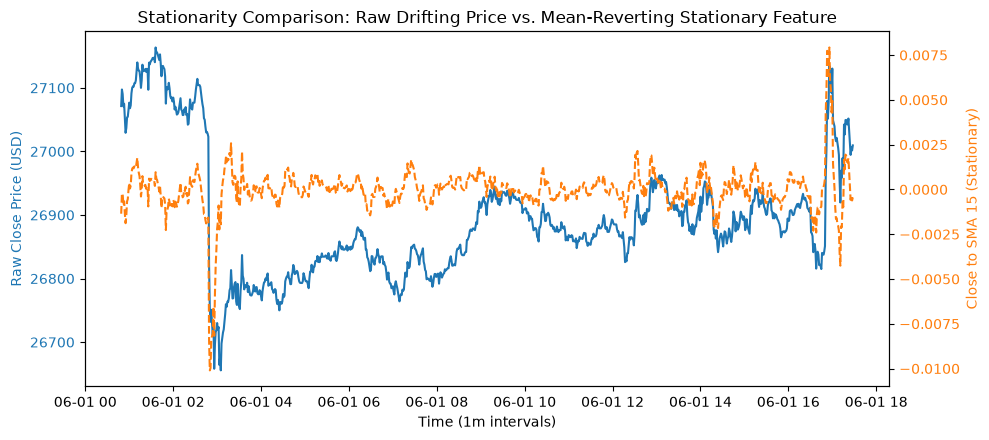

In [9]:
# Plot Close vs Close to SMA 15
plot_df = df_features.head(1000).to_pandas()

fig, ax1 = plt.subplots(figsize=(10, 4.5))

color = "tab:blue"
ax1.set_xlabel("Time (1m intervals)")
ax1.set_ylabel("Raw Close Price (USD)", color=color)
ax1.plot(plot_df["open_time"], plot_df["close"], color=color, label="Close Price")
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "tab:orange"
ax2.set_ylabel("Close to SMA 15 (Stationary)", color=color)
ax2.plot(
    plot_df["open_time"],
    plot_df["close_to_sma_15"],
    color=color,
    linestyle="--",
    label="Close to SMA 15",
)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Stationarity Comparison: Raw Drifting Price vs. Mean-Reverting Stationary Feature")
fig.tight_layout()
plt.show()

### Interpretation of Stationarity:
- The raw Close Price drifts upward/downward and is non-stationary, meaning its mean and variance change over time.
- The `close_to_sma_15` feature oscillates around a constant mean of 0 with a stable variance. By transforming nominal prices into stationary percentage offsets, we ensure the model learns patterns that generalize across all price regimes (e.g. from $30k BTC to $100k BTC).

## Feature Interaction with Target Variable
We compute the future binary price movement target (direction classification target representing return over the future horizon $N$) and inspect how our features vary between the target classes.

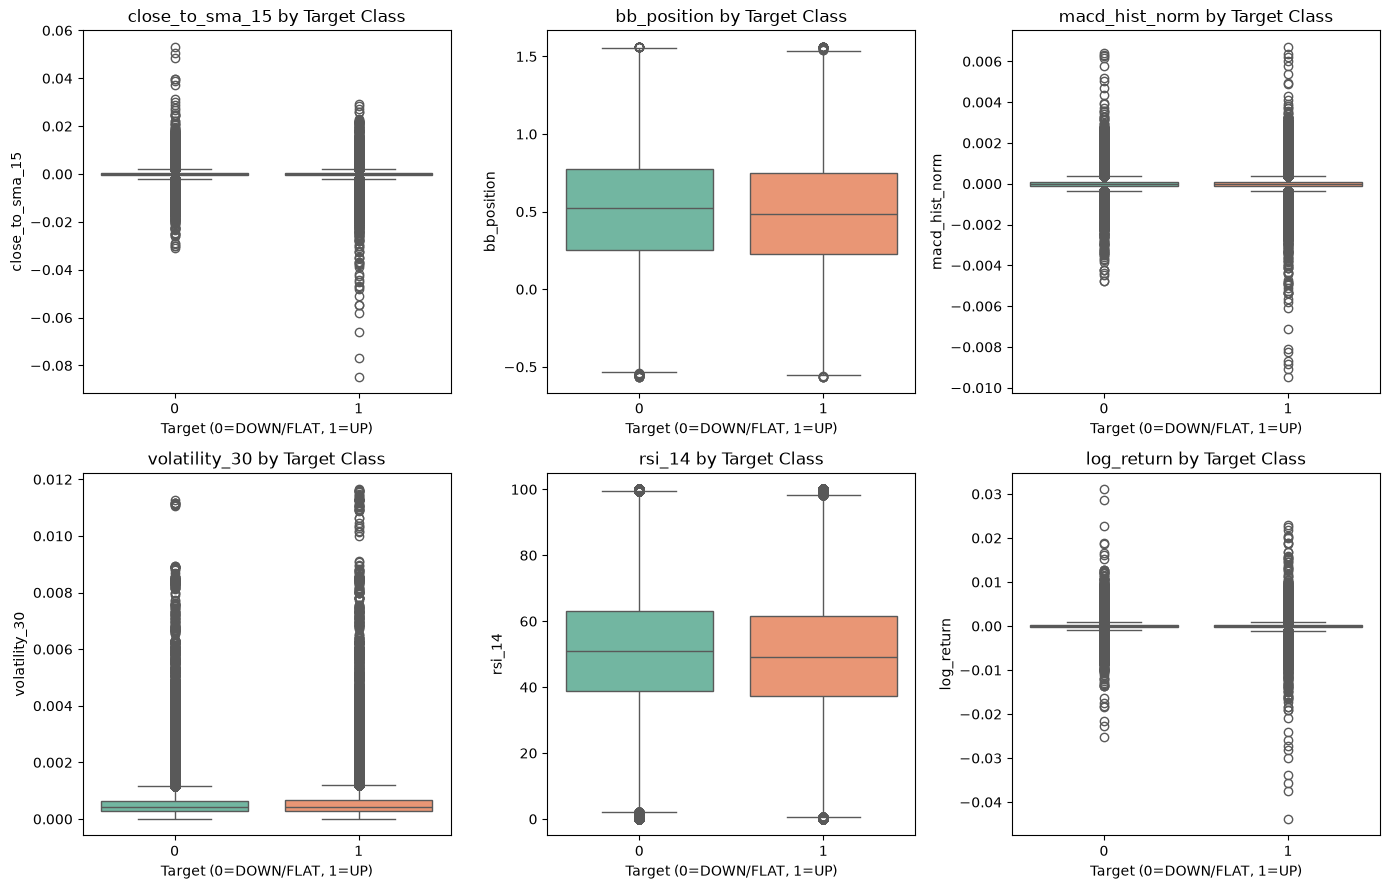

In [10]:
# Compute target label using the Spark pipeline
from src.models.train_spark import compute_targets_spark

df_labeled_spark = compute_targets_spark(df_features_spark, feature_cols)

# Convert to Polars DataFrame for downstream compatibilities
df_labeled = pl.from_pandas(df_labeled_spark.toPandas())
df_labeled_pd = df_labeled[[*feature_cols, "target", "future_return"]].to_pandas()

# Plot boxplots of features grouped by the binary target label
plot_features = [
    "close_to_sma_15",
    "bb_position",
    "macd_hist_norm",
    "volatility_30",
    "rsi_14",
    "log_return",
]
plt.figure(figsize=(14, 9))
for i, col in enumerate(plot_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x="target", y=col, data=df_labeled_pd, hue="target", palette="Set2", legend=False)
    plt.title(f"{col} by Target Class")
    plt.xlabel("Target (0=DOWN/FLAT, 1=UP)")
plt.tight_layout()
plt.show()

In [11]:
# Compute correlation of each feature with the future return
corrs = df_labeled_pd[feature_cols].corrwith(df_labeled_pd["future_return"])
print("Pearson Correlation of Features with Future Return:")
print(corrs.sort_values(ascending=False))

Pearson Correlation of Features with Future Return:
volatility_30       0.014297
volume_z30          0.002458
hour_cos            0.001406
trades_z30          0.000979
hour_sin            0.000006
taker_buy_ratio    -0.002756
log_return         -0.008655
rsi_14             -0.009571
bb_position        -0.011535
macd_signal_norm   -0.011536
macd_hist_norm     -0.015197
macd_line_norm     -0.015444
close_to_sma_50    -0.018054
close_to_ema_50    -0.019703
close_to_sma_15    -0.020839
close_to_ema_15    -0.020994
dtype: float64


### Interpretation of Target Interactions:
- **Low Linear Correlation**: The Pearson correlation values of features with the future return are very close to zero (typically $< 0.01$). This is expected in high-frequency markets, indicating that predicting price movements at a 1-minute interval is highly challenging and linear relationships are very weak.
- **Non-Linear Dynamics**: The target class distributions (UP vs. DOWN) overlap heavily in the boxplots. The classifiers will need to utilize non-linear interactions and joint feature combinations to extract predictive signals.

## References

1. Binance Public Data — historical spot 1-minute k-lines. https://github.com/binance/binance-public-data
2. Wilder, J. W. (1978). *New Concepts in Technical Trading Systems* — RSI definition.
3. Bollinger, J. (2001). *Bollinger on Bollinger Bands* — Bollinger Bands definition.
4. Appel, G. (2005). *Technical Analysis: Power Tools for Active Investors* — MACD definition.
5. Zaharia et al. (2016). Apache Spark: A Unified Engine for Big Data Processing. CACM 59(11).